Load the data, explore the data, verify the data is correct.

**Scoring:** Half-PPR (0.5 pts per reception). nflreadpy has no half-PPR option, so fetch_stats computes it as (standard + PPR) / 2.

**ADP:** Manually download FantasyPros CSVs to `data/raw/`, fix apostrophes in names (curly → straight), then run fetch_adp. Output: player_name, season, adp only. Match to nflreadpy by player name for team/position.

In [1]:
# Import the necessary libraries
import polars as pl
import matplotlib.pyplot as plt

# Disable column limits and wrapping
# Set the number of columns to show (-1 means all columns)
# pl.Config.set_tbl_cols(-1)

# You may also need to expand the character width to prevent wrapping
# pl.Config.set_tbl_width_chars(-1)

# Run the fetch_stat.py script
# !uv run python ../scripts/fetch_stats.py

# Run the fetch_roster.py script
# !uv run python ../scripts/fetch_rosters.py

# Run the fetch_adp.py script
# !uv run python ../scripts/fetch_adp.py

# Load the seasonal data from the csv file
seasonal_stats = pl.read_csv("../data/raw/player_stats_2018_2025_season.csv", separator="\t")

# Load the weekly data from the csv file
weekly_stats = pl.read_csv("../data/raw/player_stats_2018_2025_weekly.csv", separator="\t")

# Load ADP (player_name, season, adp — match to stats by name)
adp = pl.read_csv("../data/raw/adp_combined.csv")

## 1. What does the data look like?
   - `df.shape` — how many rows and columns?
   - `df.head(10)` — what does a row look like?
   - `df.dtypes` — what types are the columns?
   - `df.describe()` — basic stats (mean, min, max)
   - `df.columns` — what are all the columns?
 

In [35]:
# Explore the weekly stats
print(f"Weekly stats shape: {weekly_stats.shape}")
print(f"Weekly stats head: {weekly_stats.head(10)}")
print(f"Weekly stats dtypes: {weekly_stats.dtypes}")
print(f"Weekly stats describe: {weekly_stats.describe()}")
print(f"Weekly stats columns: {weekly_stats.columns}")

# Explore the seasonal stats
print(f"Seasonal stats shape: {seasonal_stats.shape}")
print(f"Seasonal stats head: {seasonal_stats.head(10)}")
print(f"Seasonal stats dtypes: {seasonal_stats.dtypes}")
print(f"Seasonal stats describe: {seasonal_stats.describe()}")
print(f"Seasonal stats columns: {seasonal_stats.columns}")

Weekly stats shape: (48046, 116)
Weekly stats head: shape: (10, 116)
┌────────────┬────────────┬───────────┬──────────┬───┬───────────┬───────────┬─────────┬───────────┐
│ player_id  ┆ player_nam ┆ player_di ┆ position ┆ … ┆ fantasy_p ┆ fantasy_p ┆ game_id ┆ fantasy_p │
│ ---        ┆ e          ┆ splay_nam ┆ ---      ┆   ┆ oints     ┆ oints_ppr ┆ ---     ┆ oints_hal │
│ str        ┆ ---        ┆ e         ┆ str      ┆   ┆ ---       ┆ ---       ┆ str     ┆ f_ppr     │
│            ┆ str        ┆ ---       ┆          ┆   ┆ f64       ┆ f64       ┆         ┆ ---       │
│            ┆            ┆ str       ┆          ┆   ┆           ┆           ┆         ┆ f64       │
╞════════════╪════════════╪═══════════╪══════════╪═══╪═══════════╪═══════════╪═════════╪═══════════╡
│ 00-0004091 ┆ P.Dawson   ┆ Phil      ┆ K        ┆ … ┆ 0.0       ┆ 0.0       ┆ null    ┆ 0.0       │
│            ┆            ┆ Dawson    ┆          ┆   ┆           ┆           ┆         ┆           │
│ 00-0004091 ┆ P.Dawso

#### Look at nflreadpy functions

In [3]:
import nflreadpy as nfl
import polars.selectors as cs
# Look at load_ff_playerids()
ff_playerids = nfl.load_ff_playerids()
print(f"ff_playerids head: {ff_playerids.head(10)}")
print(f"ff_playerids columns: {ff_playerids.columns}")

# Look at ids for Christian McCaffrey from various nflreadpy functions
cmc_ids_load_ff_playerids = (
    ff_playerids.filter(pl.col("name") == "Christian McCaffrey")
    .select(
        pl.col("name"), # Included so you know who the IDs belong to
        cs.contains("id")
    )
)

print(cmc_ids_load_ff_playerids)

# Get cmc gs_id
cmc_gs_id = cmc_ids_load_ff_playerids.filter(pl.col("name") == "Christian McCaffrey")["gsis_id"]
print(f"cmc_gs_id: {cmc_gs_id}")

# Get cmc_id from load_player_stats
cmc_id_load_player_stats = (
    seasonal_stats.filter(pl.col("player_display_name") == "Christian McCaffrey")
    .select(
        pl.col("player_display_name"),
        cs.contains("id")
    )
)

print(cmc_id_load_player_stats)

ff_playerids head: shape: (10, 35)
┌────────┬──────────────┬──────────────┬────────────┬───┬────────┬────────┬────────────┬───────────┐
│ mfl_id ┆ sportradar_i ┆ fantasypros_ ┆ gsis_id    ┆ … ┆ height ┆ weight ┆ college    ┆ db_season │
│ ---    ┆ d            ┆ id           ┆ ---        ┆   ┆ ---    ┆ ---    ┆ ---        ┆ ---       │
│ i64    ┆ ---          ┆ ---          ┆ str        ┆   ┆ i64    ┆ i64    ┆ str        ┆ i64       │
│        ┆ str          ┆ i64          ┆            ┆   ┆        ┆        ┆            ┆           │
╞════════╪══════════════╪══════════════╪════════════╪═══╪════════╪════════╪════════════╪═══════════╡
│ 17030  ┆ 3c76cab3-3df ┆ 24755        ┆ 00-0040676 ┆ … ┆ 74     ┆ 219    ┆ Miami (FL) ┆ 2025      │
│        ┆ 2-43dd-acaa- ┆              ┆            ┆   ┆        ┆        ┆            ┆           │
│        ┆ 57e055…      ┆              ┆            ┆   ┆        ┆        ┆            ┆           │
│ 17031  ┆ 270e09bc-8bf ┆ 25968        ┆ 00-0040668 ┆ … 

In [4]:
# Explore load_ff_rankings()
ff_rankings = nfl.load_ff_rankings(type="draft")
print(f"ff_rankings head: {ff_rankings.head()}")
print(f"ff_rankings columns: {ff_rankings.columns}")

# Look at load_ff_rankings() for Christian McCaffrey
cmc_ff_rankings = (
    ff_rankings.filter(pl.col("player") == "Christian McCaffrey")
)

print(cmc_ff_rankings)

ff_rankings head: shape: (5, 25)
┌───────────────┬───────────┬──────────┬──────────────┬───┬─────┬──────────────┬─────────────┬─────┐
│ fp_page       ┆ page_type ┆ ecr_type ┆ player       ┆ … ┆ bye ┆ mergename    ┆ scrape_date ┆ tm  │
│ ---           ┆ ---       ┆ ---      ┆ ---          ┆   ┆ --- ┆ ---          ┆ ---         ┆ --- │
│ str           ┆ str       ┆ str      ┆ str          ┆   ┆ i64 ┆ str          ┆ str         ┆ str │
╞═══════════════╪═══════════╪══════════╪══════════════╪═══╪═════╪══════════════╪═════════════╪═════╡
│ /nfl/rankings ┆ best-dst  ┆ bp       ┆ Denver       ┆ … ┆ 12  ┆ Denver       ┆ 2026-04-03  ┆ DEN │
│ /best-ball-ds ┆           ┆          ┆ Broncos      ┆   ┆     ┆ Broncos      ┆             ┆     │
│ t.ph…         ┆           ┆          ┆              ┆   ┆     ┆              ┆             ┆     │
│ /nfl/rankings ┆ best-dst  ┆ bp       ┆ Philadelphia ┆ … ┆ 9   ┆ Philadelphia ┆ 2026-04-03  ┆ PHI │
│ /best-ball-ds ┆           ┆          ┆ Eagles       ┆   

In [5]:
# Look at all ECR rankings for redraft and compare to ADP
ecr_redraft = (
    ff_rankings.filter(pl.col("page_type") == "redraft-overall")
    .select(
        pl.col("ecr"),
        pl.col("player"),
        pl.col("team"),
        pl.col("pos"),
        pl.col("page_type")
    )
    .sort("ecr")
)

print(ecr_redraft)

# Get 2025 ADP values from ADP csv
adp_2025 = adp.filter(pl.col("season") == 2025)

print(adp_2025)


shape: (383, 5)
┌────────┬────────────────────┬──────┬─────┬─────────────────┐
│ ecr    ┆ player             ┆ team ┆ pos ┆ page_type       │
│ ---    ┆ ---                ┆ ---  ┆ --- ┆ ---             │
│ f64    ┆ str                ┆ str  ┆ str ┆ str             │
╞════════╪════════════════════╪══════╪═════╪═════════════════╡
│ 1.89   ┆ Ja'Marr Chase      ┆ CIN  ┆ WR  ┆ redraft-overall │
│ 2.11   ┆ Puka Nacua         ┆ LAR  ┆ WR  ┆ redraft-overall │
│ 2.17   ┆ Bijan Robinson     ┆ ATL  ┆ RB  ┆ redraft-overall │
│ 4.0    ┆ Jaxon Smith-Njigba ┆ SEA  ┆ WR  ┆ redraft-overall │
│ 4.83   ┆ Jahmyr Gibbs       ┆ DET  ┆ RB  ┆ redraft-overall │
│ …      ┆ …                  ┆ …    ┆ …   ┆ …               │
│ 357.0  ┆ Thomas Fidone II   ┆ NYG  ┆ TE  ┆ redraft-overall │
│ 357.67 ┆ Zach Ertz          ┆ FA   ┆ TE  ┆ redraft-overall │
│ 358.0  ┆ Max Klare          ┆ FA   ┆ TE  ┆ redraft-overall │
│ 360.0  ┆ Michael Trigg      ┆ FA   ┆ TE  ┆ redraft-overall │
│ 363.0  ┆ Taysom Hill        ┆ FA   ┆ 

In [6]:
# Look at load_ff_opportunity()
ff_opportunity = nfl.load_ff_opportunity()
print(f"ff_opportunity head: {ff_opportunity.head()}")
print(f"ff_opportunity columns: {ff_opportunity.columns}")

ff_opportunity head: shape: (5, 159)
┌────────┬─────────┬──────┬─────────────┬───┬─────────────┬─────────────┬─────────────┬────────────┐
│ season ┆ posteam ┆ week ┆ game_id     ┆ … ┆ total_first ┆ total_fanta ┆ total_fanta ┆ total_fant │
│ ---    ┆ ---     ┆ ---  ┆ ---         ┆   ┆ _down_diff_ ┆ sy_points_t ┆ sy_points_e ┆ asy_points │
│ str    ┆ str     ┆ f64  ┆ str         ┆   ┆ team        ┆ eam         ┆ xp_team     ┆ _diff_team │
│        ┆         ┆      ┆             ┆   ┆ ---         ┆ ---         ┆ ---         ┆ ---        │
│        ┆         ┆      ┆             ┆   ┆ f64         ┆ f64         ┆ f64         ┆ f64        │
╞════════╪═════════╪══════╪═════════════╪═══╪═════════════╪═════════════╪═════════════╪════════════╡
│ 2025   ┆ ARI     ┆ 1.0  ┆ 2025_01_ARI ┆ … ┆ -0.31       ┆ 63.9        ┆ 75.66       ┆ -11.76     │
│        ┆         ┆      ┆ _NO         ┆   ┆             ┆             ┆             ┆            │
│ 2025   ┆ ARI     ┆ 1.0  ┆ 2025_01_ARI ┆ … ┆ -0.31   

## 2. Display top scoring players from 2024 (Half-PPR)
- Look at https://www.fantasypros.com/nfl/stats/wr.php?year=2024&scoring=HALF&roster=y&range=custom&start_week=1&end_week=17 and compare scoring

In [7]:
# Top scorers overall
top_overall = seasonal_stats.filter(pl.col("season") == 2024).sort("seasonal_fantasy_points", descending=True).head(10)
print(f"Top 10 scorers overall in 2024:")
print(top_overall.select(["player_display_name", "position", "seasonal_fantasy_points", "overall_points_rank", "position_points_rank"]))

# Top scorers by position (2024, Half-PPR)
for pos in ["QB", "WR", "RB", "TE"]:
    top = (
        seasonal_stats.filter(pl.col("position") == pos)
        .filter(pl.col("season") == 2024)
        .sort("seasonal_fantasy_points", descending=True)
        .head(10)
    )
    print(f"\n--- Top {pos}s ---")
    print(top.select(["player_display_name", "seasonal_fantasy_points", "overall_points_rank", "position_points_rank"]))


Top 10 scorers overall in 2024:
shape: (10, 5)
┌─────────────────────┬──────────┬─────────────────────┬─────────────────────┬─────────────────────┐
│ player_display_name ┆ position ┆ seasonal_fantasy_po ┆ overall_points_rank ┆ position_points_ran │
│ ---                 ┆ ---      ┆ ints                ┆ ---                 ┆ k                   │
│ str                 ┆ str      ┆ ---                 ┆ i64                 ┆ ---                 │
│                     ┆          ┆ f64                 ┆                     ┆ i64                 │
╞═════════════════════╪══════════╪═════════════════════╪═════════════════════╪═════════════════════╡
│ Lamar Jackson       ┆ QB       ┆ 407.4               ┆ 1                   ┆ 1                   │
│ Josh Allen          ┆ QB       ┆ 379.04              ┆ 2                   ┆ 2                   │
│ Joe Burrow          ┆ QB       ┆ 359.84              ┆ 3                   ┆ 3                   │
│ Jayden Daniels      ┆ QB       ┆ 351.6    

## 3. Distribution of points by position


In [8]:
# Mean/median/max fantasy points per player by position (2024)
for pos in ["QB", "RB", "WR", "TE"]:
    weekly_pos = weekly_stats.filter(
        (pl.col("position") == pos) & (pl.col("season") == 2024)
    )
    dist = weekly_pos.group_by("player_display_name").agg(
        pl.col("fantasy_points_half_ppr").mean().alias("mean_fantasy_points"),
        pl.col("fantasy_points_half_ppr").median().alias("median_fantasy_points"),
        pl.col("fantasy_points_half_ppr").max().alias("max_fantasy_points"),
    )
    print(f"\n--- {pos} ---")
    print(dist.sort("mean_fantasy_points", descending=True).head(5))



--- QB ---
shape: (5, 4)
┌─────────────────────┬─────────────────────┬───────────────────────┬────────────────────┐
│ player_display_name ┆ mean_fantasy_points ┆ median_fantasy_points ┆ max_fantasy_points │
│ ---                 ┆ ---                 ┆ ---                   ┆ ---                │
│ str                 ┆ f64                 ┆ f64                   ┆ f64                │
╞═════════════════════╪═════════════════════╪═══════════════════════╪════════════════════╡
│ Lamar Jackson       ┆ 25.4625             ┆ 24.64                 ┆ 36.1               │
│ Josh Allen          ┆ 23.69               ┆ 22.54                 ┆ 51.88              │
│ Joe Burrow          ┆ 22.49               ┆ 20.9                  ┆ 36.98              │
│ Jayden Daniels      ┆ 21.975              ┆ 22.94                 ┆ 34.42              │
│ Baker Mayfield      ┆ 21.51               ┆ 22.31                 ┆ 34.56              │
└─────────────────────┴─────────────────────┴───────────────────

## 4. Missing data


In [9]:
# Check for missing data
print("Seasonal stats null counts:")
print(seasonal_stats.null_count())
print("\nWeekly stats null counts:")
print(weekly_stats.null_count())


Seasonal stats null counts:
shape: (1, 12)
┌───────────┬─────────────┬──────────┬────────┬───┬─────────────┬──────┬─────────────┬─────────────┐
│ player_id ┆ player_disp ┆ position ┆ season ┆ … ┆ seasonal_fa ┆ team ┆ overall_poi ┆ position_po │
│ ---       ┆ lay_name    ┆ ---      ┆ ---    ┆   ┆ ntasy_point ┆ ---  ┆ nts_rank    ┆ ints_rank   │
│ u32       ┆ ---         ┆ u32      ┆ u32    ┆   ┆ s_min       ┆ u32  ┆ ---         ┆ ---         │
│           ┆ u32         ┆          ┆        ┆   ┆ ---         ┆      ┆ u32         ┆ u32         │
│           ┆             ┆          ┆        ┆   ┆ u32         ┆      ┆             ┆             │
╞═══════════╪═════════════╪══════════╪════════╪═══╪═════════════╪══════╪═════════════╪═════════════╡
│ 0         ┆ 0           ┆ 0        ┆ 0      ┆ … ┆ 0           ┆ 0    ┆ 0           ┆ 0           │
└───────────┴─────────────┴──────────┴────────┴───┴─────────────┴──────┴─────────────┴─────────────┘

Weekly stats null counts:
shape: (1, 116)
┌────

## 5. Name normalization


In [10]:
from ff_ai_assistant.utils import normalize_player_name

# Test normalize_player_name
for name in ["Kenneth Walker III", "Odell Beckham Jr.", "A.J. Green", "Patrick Mahomes II", "Minnesota Vikings"]:
    print(f"{name} -> {normalize_player_name(name)}")

# Check for potential normalization bugs:
# Count the number of words in original vs. normalized names for all player_display_name in seasonal_stats

def count_words(s):
    return len(s.strip().split())

seasonal_names = seasonal_stats["player_display_name"]
normalized_names = [normalize_player_name(n) for n in seasonal_names]

word_counts_original = [count_words(n) for n in seasonal_names]
word_counts_normalized = [count_words(n) for n in normalized_names]

problem_indices = [
    i for i, (orig, norm) in enumerate(zip(word_counts_original, word_counts_normalized))
    if word_counts_original[i] > 1 and word_counts_normalized[i] < 2
]

print(f"Number of names where normalization resulted in only one word (should be 0): {len(problem_indices)}")
if problem_indices:
    print("Sample of problematic normalizations (up to 10 shown):")
    for idx in problem_indices[:10]:
        print(f"Original: '{seasonal_names[idx]}', Normalized: '{normalized_names[idx]}'")

# Add match_key to seasonal_stats and ADP
seasonal_stats = seasonal_stats.with_columns(
    pl.Series("match_key", normalized_names)
)
adp = adp.with_columns(
    pl.Series("match_key", [normalize_player_name(n) for n in adp["player_name"]])
)


Kenneth Walker III -> kenneth walker
Odell Beckham Jr. -> odell beckham
A.J. Green -> aj green
Patrick Mahomes II -> patrick mahomes
Minnesota Vikings -> minnesota vikings
Number of names where normalization resulted in only one word (should be 0): 0


## 6. Duplicate inspection & handling


In [11]:
# Aggregate traded players (one row per player_id, season)
seasonal_stats_dedup = seasonal_stats.group_by(
    ["player_id", "player_display_name", "position", "season", "match_key"]
).agg(
    pl.col("seasonal_fantasy_points").sum().alias("seasonal_fantasy_points"),
    pl.col("team").last().alias("team"),
    pl.col("seasonal_fantasy_points_mean").mean().alias("seasonal_fantasy_points_mean"),
    pl.col("seasonal_fantasy_points_median").median().alias("seasonal_fantasy_points_median"),
    pl.col("seasonal_fantasy_points_max").max().alias("seasonal_fantasy_points_max"),
    pl.col("seasonal_fantasy_points_min").min().alias("seasonal_fantasy_points_min"),
    pl.col("overall_points_rank").first().alias("overall_points_rank"),
    pl.col("position_points_rank").first().alias("position_points_rank"),
)

# Inspect collisions (same name, different players)
dup_keys = (
    seasonal_stats_dedup.group_by(["match_key", "season"])
    .agg(pl.len().alias("cnt"), pl.col("player_id").n_unique().alias("players"))
    .filter(pl.col("cnt") > 1)
)
print(f"Keys with multiple rows: {len(dup_keys)}")

# Merge ADP with stats
combined = adp.join(seasonal_stats_dedup, on=["match_key", "season"], how="left")
combined = combined.sort("seasonal_fantasy_points", descending=True)
combined = combined.unique(subset=["season", "player_name", "adp"], keep="first")

# Match rate
adp_count = len(adp)
merged_count = combined.filter(pl.col("player_id").is_not_null()).height
print(f"ADP rows: {adp_count}, Matched: {merged_count}, Match rate: {merged_count/adp_count:.1%}")


Keys with multiple rows: 1
ADP rows: 3205, Matched: 2612, Match rate: 81.5%


#### Debug unmatched names

In [12]:
# Unmatched ADP rows
unmatched = adp.join(
    combined.filter(pl.col("player_id").is_not_null()).select(["match_key", "season"]).unique(),
    on=["match_key", "season"],
    how="anti"
)

# By position (if ADP has position) or by season
print("Unmatched count:", len(unmatched))
print(unmatched)

Unmatched count: 593
shape: (593, 4)
┌────────┬──────────────────────┬───────┬──────────────────────┐
│ season ┆ player_name          ┆ adp   ┆ match_key            │
│ ---    ┆ ---                  ┆ ---   ┆ ---                  │
│ i64    ┆ str                  ┆ f64   ┆ str                  │
╞════════╪══════════════════════╪═══════╪══════════════════════╡
│ 2018   ┆ Le'Veon Bell         ┆ 2.0   ┆ leveon bell          │
│ 2018   ┆ William Fuller V     ┆ 76.5  ┆ william fuller       │
│ 2018   ┆ Jacksonville Jaguars ┆ 95.0  ┆ jacksonville jaguars │
│ 2018   ┆ Los Angeles Rams     ┆ 106.0 ┆ los angeles rams     │
│ 2018   ┆ Minnesota Vikings    ┆ 111.0 ┆ minnesota vikings    │
│ …      ┆ …                    ┆ …     ┆ …                    │
│ 2025   ┆ Xavier Johnson       ┆ 362.0 ┆ xavier johnson       │
│ 2025   ┆ Audric Estime        ┆ 369.0 ┆ audric estime        │
│ 2025   ┆ John Ursua           ┆ 371.0 ┆ john ursua           │
│ 2025   ┆ Zach Horton          ┆ 373.0 ┆ zach horton

## 7. ID-based matching via ff_playerids

Name-based merge got ~81.5%. A lot of the misses are DST teams and players who never played,
but there are real name mismatches too (e.g. "William Fuller V" vs "Will Fuller").

Try using `load_ff_playerids()` as a bridge table — it has `gsis_id` (same as `player_id` in stats)
and `merge_name` (a pre-cleaned name). Join chain:

1. ADP → ff_playerids on normalized name → get `gsis_id`
2. That result → seasonal_stats on `gsis_id` + `season`

Should avoid name collision issues since `gsis_id` is unique per player.

Filter DSTs out of ADP before matching (team defenses don't appear in player stats). Optionally compare match rate with vs without DSTs.

In [13]:
# DST pattern: FantasyPros ADP lists defenses as "City Team" (e.g. "Jacksonville Jaguars")
DST_PATTERN = (
    r"(?i)(jaguars|rams|bears|eagles|broncos|vikings|saints|49ers|ravens|steelers|"
    r"chiefs|chargers|seahawks|cowboys|lions|bengals|texans|jets|bills|colts|titans|"
    r"patriots|panthers|dolphins|giants|falcons|packers|cardinals|commanders|raiders|browns|buccaneers)$"
)

adp_no_dst = adp.filter(~pl.col("player_name").str.contains(DST_PATTERN))
dst_count = len(adp) - len(adp_no_dst)

print(f"Full ADP rows: {len(adp)}")
print(f"DST rows removed: {dst_count}")
print(f"ADP for matching (no DST): {len(adp_no_dst)}")

Full ADP rows: 3205
DST rows removed: 221
ADP for matching (no DST): 2984


In [14]:
# ff_playerids was loaded in the nflreadpy exploration cells above.
# Build a lookup: merge_name -> gsis_id (one row per player)
# Some players share a merge_name, so also keep position to disambiguate
id_bridge = (
    ff_playerids
    .filter(pl.col("gsis_id").is_not_null())
    .select(["gsis_id", "merge_name", "position"])
    .unique(subset=["gsis_id"])
)

print(f"ID bridge rows: {id_bridge.shape[0]}")
print(f"Unique merge_names: {id_bridge['merge_name'].n_unique()}")
print(id_bridge.head(10))

ID bridge rows: 7705
Unique merge_names: 7581
shape: (10, 3)
┌────────────┬──────────────────┬──────────┐
│ gsis_id    ┆ merge_name       ┆ position │
│ ---        ┆ ---              ┆ ---      │
│ str        ┆ str              ┆ str      │
╞════════════╪══════════════════╪══════════╡
│ 00-0026647 ┆ tj conley        ┆ PN       │
│ 00-0032240 ┆ vic beasley      ┆ LB       │
│ 00-0038640 ┆ jalen brooks     ┆ WR       │
│ 00-0034434 ┆ kendrick norton  ┆ DT       │
│ 00-0036387 ┆ jalen reagor     ┆ WR       │
│ 00-0040711 ┆ cj west          ┆ DT       │
│ 00-0029571 ┆ kheeston randall ┆ DT       │
│ 00-0025439 ┆ brian leonard    ┆ RB       │
│ 00-0032080 ┆ titus davis      ┆ WR       │
│ 00-0031962 ┆ mario alford     ┆ WR       │
└────────────┴──────────────────┴──────────┘


In [15]:
from ff_ai_assistant.utils import normalize_player_name

# The ff_playerids merge_name is already lowercased and stripped of suffixes/punctuation.
# Our normalize_player_name does the same thing. Let's compare them on a few names
# to see if they produce the same output.
test_names_in_ids = ff_playerids.filter(
    pl.col("name").is_in(["Kenneth Walker III", "A.J. Brown", "Ja'Marr Chase", "Patrick Mahomes II"])
).select(["name", "merge_name"])
print("ff_playerids merge_name examples:")
print(test_names_in_ids)

# Our normalize function output for comparison
for name in ["Kenneth Walker III", "A.J. Brown", "Ja'Marr Chase", "Patrick Mahomes II"]:
    print(f"  normalize_player_name('{name}') -> '{normalize_player_name(name)}'")

ff_playerids merge_name examples:
shape: (3, 2)
┌────────────────────┬────────────────┐
│ name               ┆ merge_name     │
│ ---                ┆ ---            │
│ str                ┆ str            │
╞════════════════════╪════════════════╡
│ Kenneth Walker III ┆ kenneth walker │
│ Ja'Marr Chase      ┆ jamarr chase   │
│ A.J. Brown         ┆ aj brown       │
└────────────────────┴────────────────┘
  normalize_player_name('Kenneth Walker III') -> 'kenneth walker'
  normalize_player_name('A.J. Brown') -> 'aj brown'
  normalize_player_name('Ja'Marr Chase') -> 'jamarr chase'
  normalize_player_name('Patrick Mahomes II') -> 'patrick mahomes'


In [16]:
# Use match_key to join ADP (no DST) -> ff_playerids -> stats.
# Step 1: Add match_key to the bridge table so we can join on it
id_bridge = id_bridge.with_columns(
    pl.Series("match_key", [normalize_player_name(n) for n in id_bridge["merge_name"]])
)

# Step 2: Join ADP (no DST) to bridge on match_key to get gsis_id
adp_with_ids = adp_no_dst.join(
    id_bridge.select(["match_key", "gsis_id"]),
    on="match_key",
    how="left",
)

# Some match_keys map to multiple gsis_ids (e.g. two "Mike Williams" players).
# Deduplicate: keep one per (season, player_name, adp) — we'll resolve in the stats join.
adp_with_ids = adp_with_ids.unique(subset=["season", "player_name", "adp", "gsis_id"])

id_bridge_count = adp_with_ids.filter(pl.col("gsis_id").is_not_null()).height
print(f"ADP rows (no DST): {len(adp_no_dst)}")
print(f"ADP rows with gsis_id from bridge: {id_bridge_count} ({id_bridge_count/len(adp_no_dst):.1%})")
print(f"ADP rows without gsis_id: {len(adp_no_dst) - id_bridge_count}")

ADP rows (no DST): 2984
ADP rows with gsis_id from bridge: 2941 (98.6%)
ADP rows without gsis_id: 43


In [17]:
# Step 3: Aggregate traded players (one row per player_id + season). Keep match_key for name fallback.
seasonal_stats_dedup = seasonal_stats.group_by(
    ["player_id", "player_display_name", "position", "season", "match_key"]
).agg(
    pl.col("seasonal_fantasy_points").sum().alias("seasonal_fantasy_points"),
    pl.col("team").last().alias("team"),
    pl.col("seasonal_fantasy_points_mean").mean().alias("seasonal_fantasy_points_mean"),
    pl.col("seasonal_fantasy_points_median").median().alias("seasonal_fantasy_points_median"),
    pl.col("seasonal_fantasy_points_max").max().alias("seasonal_fantasy_points_max"),
    pl.col("seasonal_fantasy_points_min").min().alias("seasonal_fantasy_points_min"),
    pl.col("overall_points_rank").first().alias("overall_points_rank"),
    pl.col("position_points_rank").first().alias("position_points_rank"),
)

# Step 4: Hybrid matching — ID first, then name fallback for ADP rows that didn't match via ID.
# 4a. Match via gsis_id + season
id_joined = adp_with_ids.join(
    seasonal_stats_dedup,
    left_on=["gsis_id", "season"],
    right_on=["player_id", "season"],
    how="left",
)
id_matched = id_joined.filter(pl.col("player_display_name").is_not_null())

# 4b. ADP rows that still have no stats — try name-based join
adp_unmatched_by_id = adp_with_ids.join(
    id_matched.select(["season", "player_name", "adp"]),
    on=["season", "player_name", "adp"],
    how="anti",
)
name_matched = adp_unmatched_by_id.join(
    seasonal_stats_dedup,
    on=["match_key", "season"],
    how="inner",
)

# 4c. Combine and deduplicate (keep one row per season/player_name/adp, prefer higher fantasy points)
# Align column order so concat works (id_joined and name_matched have different column order from their joins)
common_cols = [c for c in id_matched.columns if c in name_matched.columns]
combined = pl.concat([id_matched.select(common_cols), name_matched.select(common_cols)])
combined = combined.sort("seasonal_fantasy_points", descending=True, nulls_last=True)
combined = combined.unique(subset=["season", "player_name", "adp"], keep="first")

# Match rate on ADP without DST
matched = combined.height
print(f"Hybrid match rate (ADP no DST): {matched}/{len(adp_no_dst)} = {matched/len(adp_no_dst):.1%}")
print(f"For comparison: match rate on full ADP (with DST) would be {matched}/{len(adp)} = {matched/len(adp):.1%}")

Hybrid match rate (ADP no DST): 2619/2984 = 87.8%
For comparison: match rate on full ADP (with DST) would be 2619/3205 = 81.7%


In [18]:
# Manual overrides: (ADP player_name, season, stats match_key)
# stats match_key = normalize_player_name of the name that appears in seasonal_stats (e.g. "Will Fuller" -> "will fuller")
MANUAL_ADP_TO_STATS = [
    ("William Fuller V", 2018, "will fuller"),
    ("William Fuller V", 2019, "will fuller"),
    ("William Fuller V", 2020, "will fuller"),
    ("William Fuller V", 2021, "will fuller"),
    ("Joshua Palmer", 2021, "josh palmer"),
    ("Joshua Palmer", 2022, "josh palmer"),
    ("Joshua Palmer", 2023, "josh palmer"),
    ("Joshua Palmer", 2024, "josh palmer"),
    ("Joshua Palmer", 2025, "josh palmer"),
    ("Robert Kelley", 2018, "rob kelley"),
    ("Nyheim Miller-Hines", 2018, "nyheim hines"),
    ("Nyheim Miller-Hines", 2019, "nyheim hines"),
    ("Nyheim Miller-Hines", 2020, "nyheim hines"),
    ("Nyheim Miller-Hines", 2021, "nyheim hines"),
    ("Nyheim Miller-Hines", 2022, "nyheim hines"),
    # Add more as you find them: ("ADP name", season, "stats match_key"),
]

if MANUAL_ADP_TO_STATS:
    manual_df = pl.DataFrame(
        {
            "player_name": [x[0] for x in MANUAL_ADP_TO_STATS],
            "season": [x[1] for x in MANUAL_ADP_TO_STATS],
            "stats_match_key": [x[2] for x in MANUAL_ADP_TO_STATS],
        }
    )
    override_adp = adp_unmatched_by_id.join(manual_df, on=["player_name", "season"], how="inner")
    override_rows = override_adp.join(
        seasonal_stats_dedup,
        left_on=["stats_match_key", "season"],
        right_on=["match_key", "season"],
        how="inner",
    )
    # Same schema as combined for concat
    override_cols = [c for c in common_cols if c in override_rows.columns]
    combined = pl.concat([combined, override_rows.select(override_cols)])
    combined = combined.sort("seasonal_fantasy_points", descending=True, nulls_last=True)
    combined = combined.unique(subset=["season", "player_name", "adp"], keep="first")
    print(f"After manual overrides: {combined.height} rows matched.")
else:
    print("No manual overrides defined. Set MANUAL_ADP_TO_STATS to add name-mismatch fixes.")

After manual overrides: 2634 rows matched.


In [19]:
# What's still unmatched? (ADP rows without DST that got no stats match)
unmatched = adp_no_dst.join(
    combined.select(["season", "player_name", "adp"]),
    on=["season", "player_name", "adp"],
    how="anti",
)
unmatched = unmatched.join(
    adp_with_ids.select(["season", "player_name", "adp", "gsis_id"]),
    on=["season", "player_name", "adp"],
    how="left",
)

print(f"Unmatched count (ADP no DST): {unmatched.height}")

# No gsis_id from bridge (name not in ff_playerids or different spelling)
no_gsis = unmatched.filter(pl.col("gsis_id").is_null())
print(f"No gsis_id (not in ff_playerids): {len(no_gsis)}")
print("Sample:", no_gsis.select(["season", "player_name", "adp"]).head(10))

# Had gsis_id but no stats that season (holdout, injured, didn't play)
had_gsis_no_stats = unmatched.filter(pl.col("gsis_id").is_not_null())
print(f"\nHad gsis_id but no stats that season: {len(had_gsis_no_stats)}")
print("Sample:", had_gsis_no_stats.select(["season", "player_name", "adp"]).head(10))

Unmatched count (ADP no DST): 359
No gsis_id (not in ff_playerids): 89
Sample: shape: (10, 3)
┌────────┬──────────────────┬───────┐
│ season ┆ player_name      ┆ adp   │
│ ---    ┆ ---              ┆ ---   │
│ i64    ┆ str              ┆ f64   │
╞════════╪══════════════════╪═══════╡
│ 2018   ┆ Stephen Hauschka ┆ 269.0 │
│ 2019   ┆ Isaac Zico       ┆ 316.0 │
│ 2019   ┆ Corey Acosta     ┆ 388.0 │
│ 2019   ┆ Devonte Boyd     ┆ 399.0 │
│ 2019   ┆ Stephen Hauschka ┆ 409.0 │
│ 2020   ┆ Stephen Hauschka ┆ 299.0 │
│ 2020   ┆ Scotty Miller    ┆ 351.0 │
│ 2021   ┆ Jonathan Brown   ┆ 250.0 │
│ 2021   ┆ Nick Tiano       ┆ 251.0 │
│ 2021   ┆ Kent Taylor      ┆ 252.0 │
└────────┴──────────────────┴───────┘

Had gsis_id but no stats that season: 270
Sample: shape: (10, 3)
┌────────┬──────────────────┬───────┐
│ season ┆ player_name      ┆ adp   │
│ ---    ┆ ---              ┆ ---   │
│ i64    ┆ str              ┆ f64   │
╞════════╪══════════════════╪═══════╡
│ 2018   ┆ Le'Veon Bell     ┆ 2.0   │
│ 20

### 7.4 Name mismatch diagnostics

Some unmatched players aren't missing — they just have different names in the ADP data vs nflreadpy (e.g. "William Fuller V" vs "Will Fuller"). The cell below finds candidates by matching on last name + season. Review the output, then populate the corrections dict in the following cell.

**Duplicate gsis_ids (e.g. A.J. Green):** The bridge can map one match_key to two different gsis_ids (two players in ff_playerids with the same name). If neither id appears in that season's stats, the id-join fails. The name fallback then joins on match_key; if the stats table has "A. J. Green" (with a space) it used to normalize to "a j green" while ADP had "aj green", so they didn't match. `normalize_player_name` was updated so spaced initials ("A J") and apostrophes ("Le'Veon" / "LeVeon") are normalized the same. Re-run from the name-normalization cell so all match_keys are recomputed.

In [20]:

# Look up stats for Will Fuller
will_fuller_stats = seasonal_stats.filter(pl.col("player_display_name") == "Will Fuller")
print(will_fuller_stats)

# Look up stats for Mike Thomas
mike_thomas_stats = seasonal_stats.filter(pl.col("player_display_name") == "Mike Thomas")
print(mike_thomas_stats)

# Look up stats for Michael Thomas
michael_thomas_stats = seasonal_stats.filter(pl.col("player_display_name") == "Michael Thomas")
print(michael_thomas_stats)

# Look up stats for Joshua Palmer
joshua_palmer_stats = seasonal_stats.filter(pl.col("player_display_name") == "Josh Palmer")
print(joshua_palmer_stats)

# Look up stats for Robert Kelley
robert_kelley_stats = seasonal_stats.filter(pl.col("player_display_name") == "Rob Kelley")
print(robert_kelley_stats)

# Look up stats for AJ Green
aj_green_stats = seasonal_stats.filter(pl.col("player_display_name") == "A.J. Green")
print(aj_green_stats)

shape: (4, 13)
┌────────────┬─────────────┬──────────┬────────┬───┬──────┬─────────────┬─────────────┬────────────┐
│ player_id  ┆ player_disp ┆ position ┆ season ┆ … ┆ team ┆ overall_poi ┆ position_po ┆ match_key  │
│ ---        ┆ lay_name    ┆ ---      ┆ ---    ┆   ┆ ---  ┆ nts_rank    ┆ ints_rank   ┆ ---        │
│ str        ┆ ---         ┆ str      ┆ i64    ┆   ┆ str  ┆ ---         ┆ ---         ┆ str        │
│            ┆ str         ┆          ┆        ┆   ┆      ┆ i64         ┆ i64         ┆            │
╞════════════╪═════════════╪══════════╪════════╪═══╪══════╪═════════════╪═════════════╪════════════╡
│ 00-0033127 ┆ Will Fuller ┆ WR       ┆ 2018   ┆ … ┆ HOU  ┆ 164         ┆ 67          ┆ will       │
│            ┆             ┆          ┆        ┆   ┆      ┆             ┆             ┆ fuller     │
│ 00-0033127 ┆ Will Fuller ┆ WR       ┆ 2020   ┆ … ┆ HOU  ┆ 74          ┆ 28          ┆ will       │
│            ┆             ┆          ┆        ┆   ┆      ┆             ┆   

In [21]:
# Find likely name mismatches: unmatched ADP players with ADP < 200 (fantasy-relevant)
# For each, check if any stats player shares the same last name + season
high_adp_unmatched = unmatched.filter(pl.col("adp") < 200).sort("adp")
print(f"High ADP unmatched: {high_adp_unmatched.height}")
print(high_adp_unmatched.head(10))
print(high_adp_unmatched.tail(10))

# Extract last name from match_key (already normalized — no suffixes like V, Jr, III)
# match_key = "william fuller", so last word = "fuller"
stats_names = seasonal_stats_dedup.select(
    ["player_display_name", "match_key", "player_id", "season"]
).with_columns(
    pl.col("match_key").str.split(" ").list.last().alias("last_name")
)

high_adp_unmatched = high_adp_unmatched.with_columns(
    pl.col("match_key").str.split(" ").list.last().alias("last_name")
)

# Join on last_name + season to find candidates
candidates = high_adp_unmatched.join(
    stats_names,
    on=["last_name", "season"],
    how="inner",
    suffix="_stats",
)

if candidates.height > 0:
    print(f"Possible name mismatches ({candidates.height} candidates):")
    print(candidates.select([
        "season", "player_name", "adp", "player_display_name", "match_key", "match_key_stats", "player_id"
    ]).sort("adp"))
else:
    print("No obvious last-name matches found among high-ADP unmatched players.")

High ADP unmatched: 15
shape: (10, 5)
┌────────┬────────────────┬───────┬────────────────┬────────────┐
│ season ┆ player_name    ┆ adp   ┆ match_key      ┆ gsis_id    │
│ ---    ┆ ---            ┆ ---   ┆ ---            ┆ ---        │
│ i64    ┆ str            ┆ f64   ┆ str            ┆ str        │
╞════════╪════════════════╪═══════╪════════════════╪════════════╡
│ 2018   ┆ Le'Veon Bell   ┆ 2.0   ┆ leveon bell    ┆ 00-0030496 │
│ 2019   ┆ A.J. Green     ┆ 62.3  ┆ aj green       ┆ 00-0027942 │
│ 2019   ┆ A.J. Green     ┆ 62.3  ┆ aj green       ┆ 00-0036114 │
│ 2021   ┆ Gus Edwards    ┆ 70.8  ┆ gus edwards    ┆ 00-0034184 │
│ 2021   ┆ Michael Thomas ┆ 78.3  ┆ michael thomas ┆ 00-0028908 │
│ 2021   ┆ Michael Thomas ┆ 78.3  ┆ michael thomas ┆ 00-0032765 │
│ 2025   ┆ Joe Mixon      ┆ 95.3  ┆ joe mixon      ┆ 00-0033897 │
│ 2018   ┆ Dez Bryant     ┆ 112.0 ┆ dez bryant     ┆ 00-0027902 │
│ 2018   ┆ Marqise Lee    ┆ 113.0 ┆ marqise lee    ┆ 00-0031431 │
│ 2025   ┆ Brandon Aiyuk  ┆ 150.7 ┆ br

### 7.5 Manual name corrections

After reviewing the candidates above, add confirmed mismatches to `ADP_NAME_CORRECTIONS`. This re-matches them and adds them to `combined`.

In [22]:
# Manual name corrections: ADP name -> stats name
# Populate this dict from the candidates output above, then re-run to patch the combined table.
ADP_NAME_CORRECTIONS = {
    # "ADP player_name": "nflreadpy player_display_name"
    # e.g. "William Fuller V": "Will Fuller",
}

if ADP_NAME_CORRECTIONS:
    # Build corrected match_keys for the ADP side
    corrections_df = pl.DataFrame({
        "player_name": list(ADP_NAME_CORRECTIONS.keys()),
        "corrected_match_key": [normalize_player_name(v) for v in ADP_NAME_CORRECTIONS.values()],
    })

    # Find the ADP rows that need correction, re-match them
    adp_to_fix = adp_no_dst.join(corrections_df, on="player_name", how="inner")
    fixed_matches = adp_to_fix.join(
        seasonal_stats_dedup,
        left_on=["corrected_match_key", "season"],
        right_on=["match_key", "season"],
        how="inner",
    )

    if fixed_matches.height > 0:
        # Add to combined (select common cols, concat, deduplicate)
        fix_cols = [c for c in common_cols if c in fixed_matches.columns]
        # For any missing columns, fill with null
        for c in common_cols:
            if c not in fixed_matches.columns:
                fixed_matches = fixed_matches.with_columns(pl.lit(None).alias(c))
        combined = pl.concat([combined, fixed_matches.select(common_cols)])
        combined = combined.sort("seasonal_fantasy_points", descending=True, nulls_last=True)
        combined = combined.unique(subset=["season", "player_name", "adp"], keep="first")
        print(f"Fixed {fixed_matches.height} rows. New match rate: {combined.height}/{len(adp_no_dst)} = {combined.height/len(adp_no_dst):.1%}")
    else:
        print("No new matches from corrections.")
else:
    print("No corrections defined yet. Run the candidate cell above, review the output,")
    print("then add entries to ADP_NAME_CORRECTIONS and re-run this cell.")

No corrections defined yet. Run the candidate cell above, review the output,
then add entries to ADP_NAME_CORRECTIONS and re-run this cell.


## 8. Build the combined DataFrame

Goal: one clean table with everything needed for the next phase.
- Player identity (name, position, team)
- Season-level stats (total half-PPR points, weekly mean/median/max/min)
- ADP (draft position)
- Roster metadata (age, draft capital)

This table feeds into both the RAG layer (text documents) and analytics (value scoring).

In [23]:
# Load rosters and extract useful metadata per player-season
rosters = pl.read_csv("../data/raw/rosters_2018_2025.csv", separator="\t")
print(f"Roster shape: {rosters.shape}")
print(f"Roster columns: {rosters.columns}")
print(rosters.head(5))

Roster shape: (24862, 36)
Roster columns: ['season', 'team', 'position', 'depth_chart_position', 'jersey_number', 'status', 'full_name', 'first_name', 'last_name', 'birth_date', 'height', 'weight', 'college', 'gsis_id', 'espn_id', 'sportradar_id', 'yahoo_id', 'rotowire_id', 'pff_id', 'pfr_id', 'fantasy_data_id', 'sleeper_id', 'years_exp', 'headshot_url', 'ngs_position', 'week', 'game_type', 'status_description_abbr', 'football_name', 'esb_id', 'gsis_it_id', 'smart_id', 'entry_year', 'rookie_year', 'draft_club', 'draft_number']
shape: (5, 36)
┌────────┬──────┬──────────┬─────────────┬───┬────────────┬─────────────┬────────────┬─────────────┐
│ season ┆ team ┆ position ┆ depth_chart ┆ … ┆ entry_year ┆ rookie_year ┆ draft_club ┆ draft_numbe │
│ ---    ┆ ---  ┆ ---      ┆ _position   ┆   ┆ ---        ┆ ---         ┆ ---        ┆ r           │
│ i64    ┆ str  ┆ str      ┆ ---         ┆   ┆ i64        ┆ i64         ┆ str        ┆ ---         │
│        ┆      ┆          ┆ str         ┆   ┆  

In [24]:
# Build roster metadata: one row per player-season with age, experience, draft info
# Rosters have multiple rows per player-season (one per week), so deduplicate
roster_meta = (
    rosters
    .filter(pl.col("gsis_id").is_not_null() & (pl.col("gsis_id") != ""))
    .group_by(["gsis_id", "season"])
    .agg(
        pl.col("full_name").first().alias("roster_name"),
        pl.col("team").last().alias("roster_team"),
        pl.col("position").first().alias("roster_position"),
        pl.col("years_exp").max().alias("years_exp"),
        pl.col("birth_date").first().alias("birth_date"),
        pl.col("height").first().alias("height"),
        pl.col("weight").first().alias("weight"),
        pl.col("college").first().alias("college"),
        pl.col("draft_number").first().alias("draft_number"),
        pl.col("entry_year").first().alias("entry_year"),
    )
)

print(f"Roster metadata: {roster_meta.shape[0]} player-seasons")
print(roster_meta.head(5))

Roster metadata: 24850 player-seasons
shape: (5, 12)
┌────────────┬────────┬────────────┬────────────┬───┬────────┬────────────┬────────────┬───────────┐
│ gsis_id    ┆ season ┆ roster_nam ┆ roster_tea ┆ … ┆ weight ┆ college    ┆ draft_numb ┆ entry_yea │
│ ---        ┆ ---    ┆ e          ┆ m          ┆   ┆ ---    ┆ ---        ┆ er         ┆ r         │
│ str        ┆ i64    ┆ ---        ┆ ---        ┆   ┆ i64    ┆ str        ┆ ---        ┆ ---       │
│            ┆        ┆ str        ┆ str        ┆   ┆        ┆            ┆ i64        ┆ i64       │
╞════════════╪════════╪════════════╪════════════╪═══╪════════╪════════════╪════════════╪═══════════╡
│ 00-0038735 ┆ 2024   ┆ Princeton  ┆ DAL        ┆ … ┆ 240    ┆ Tennessee  ┆ null       ┆ 2023      │
│            ┆        ┆ Fant       ┆            ┆   ┆        ┆            ┆            ┆           │
│ 00-0030387 ┆ 2022   ┆ Steven     ┆ BAL        ┆ … ┆ 263    ┆ Buffalo    ┆ 147        ┆ 2013      │
│            ┆        ┆ Means      ┆  

In [25]:
# Build the final combined DataFrame:
# Start with stats (the most complete dataset), then left-join ADP and roster metadata

# Only keep matched ADP rows (ones that found stats)
adp_matched = combined.filter(pl.col("player_display_name").is_not_null()).select(
    ["gsis_id", "season", "adp", "player_name"]
).rename({"gsis_id": "player_id", "player_name": "adp_player_name"})

# Join stats with ADP
final = seasonal_stats_dedup.join(
    adp_matched,
    on=["player_id", "season"],
    how="left",
)

# Join with roster metadata
final = final.join(
    roster_meta,
    left_on=["player_id", "season"],
    right_on=["gsis_id", "season"],
    how="left",
)

# Calculate ADP value: negative means outperformed their ADP (good pick)
# We'll use position rank vs ADP rank for this later
print(f"Final combined shape: {final.shape}")
print(f"Players with ADP: {final.filter(pl.col('adp').is_not_null()).height}")
print(f"Players without ADP: {final.filter(pl.col('adp').is_null()).height}")
print(f"\nColumns: {final.columns}")
print(final.sort("seasonal_fantasy_points", descending=True).head(10).select(
    ["player_display_name", "position", "team", "season", "seasonal_fantasy_points", "adp"]
))

Final combined shape: (5056, 25)
Players with ADP: 2607
Players without ADP: 2449

Columns: ['player_id', 'player_display_name', 'position', 'season', 'match_key', 'seasonal_fantasy_points', 'team', 'seasonal_fantasy_points_mean', 'seasonal_fantasy_points_median', 'seasonal_fantasy_points_max', 'seasonal_fantasy_points_min', 'overall_points_rank', 'position_points_rank', 'adp', 'adp_player_name', 'roster_name', 'roster_team', 'roster_position', 'years_exp', 'birth_date', 'height', 'weight', 'college', 'draft_number', 'entry_year']
shape: (10, 6)
┌─────────────────────┬──────────┬──────┬────────┬─────────────────────────┬───────┐
│ player_display_name ┆ position ┆ team ┆ season ┆ seasonal_fantasy_points ┆ adp   │
│ ---                 ┆ ---      ┆ ---  ┆ ---    ┆ ---                     ┆ ---   │
│ str                 ┆ str      ┆ str  ┆ i64    ┆ f64                     ┆ f64   │
╞═════════════════════╪══════════╪══════╪════════╪═════════════════════════╪═══════╡
│ Patrick Mahomes     ┆

### 8.1 Include drafted players who didn't play

Players who had an ADP but produced no stats (holdouts, injured preseason, etc.) are still useful context for the RAG. A document saying "Le'Veon Bell was ADP 2 in 2018 and scored 0 points" is directly relevant to draft advice. These rows get zero for all stat columns.

In [26]:
# ADP rows that still have no stats match (after corrections)
# These are players who were drafted but didn't produce stats that season
drafted_no_stats = adp_no_dst.join(
    combined.select(["season", "player_name", "adp"]),
    on=["season", "player_name", "adp"],
    how="anti",
)

# Add gsis_id and position (position comes from ff_playerids bridge; ADP CSV doesn't have it)
drafted_no_stats = drafted_no_stats.join(
    adp_with_ids.select(["season", "player_name", "adp", "gsis_id"]),
    on=["season", "player_name", "adp"],
    how="left",
)
drafted_no_stats = drafted_no_stats.join(
    id_bridge.select(["gsis_id", "position"]),
    on="gsis_id",
    how="left",
)
# Rows without gsis_id get null position; use "UNK" so the column is non-null for concat
drafted_no_stats = drafted_no_stats.with_columns(
    pl.col("position").fill_null("UNK")
)

# Build rows that match final's schema, with 0 for stat columns and null for missing metadata
stat_cols = [c for c in final.columns if "fantasy_points" in c]
meta_cols = [c for c in final.columns if c not in stat_cols + [
    "player_id", "player_display_name", "position", "season", "match_key",
    "adp", "adp_player_name", "team"
]]

no_stats_rows = drafted_no_stats.select([
    pl.col("gsis_id").alias("player_id"),
    pl.col("player_name").alias("player_display_name"),
    pl.col("position"),
    pl.col("season"),
    pl.col("match_key"),
    pl.col("adp"),
    pl.col("player_name").alias("adp_player_name"),
    pl.lit(None).cast(pl.Utf8).alias("team"),
])

# Add zero stat columns
for c in stat_cols:
    no_stats_rows = no_stats_rows.with_columns(pl.lit(0.0).alias(c))

# Add null metadata columns (roster info won't exist for players who didn't play)
for c in meta_cols:
    if c not in no_stats_rows.columns:
        dtype = final.schema[c]
        no_stats_rows = no_stats_rows.with_columns(pl.lit(None).cast(dtype).alias(c))

# Align column order and append
no_stats_rows = no_stats_rows.select(final.columns)
final_with_holdouts = pl.concat([final, no_stats_rows])

print(f"Drafted but didn't play: {no_stats_rows.height} player-seasons")
print(f"Final table before: {final.shape[0]} rows")
print(f"Final table after:  {final_with_holdouts.shape[0]} rows")
print("\nSample holdout rows:")
print(no_stats_rows.filter(pl.col("adp") < 50).sort("adp").select(
    ["player_display_name", "position", "season", "adp", "seasonal_fantasy_points"]
).head(10))

# Replace final with the expanded version
final = final_with_holdouts

Drafted but didn't play: 359 player-seasons
Final table before: 5056 rows
Final table after:  5415 rows

Sample holdout rows:
shape: (1, 5)
┌─────────────────────┬──────────┬────────┬─────┬─────────────────────────┐
│ player_display_name ┆ position ┆ season ┆ adp ┆ seasonal_fantasy_points │
│ ---                 ┆ ---      ┆ ---    ┆ --- ┆ ---                     │
│ str                 ┆ str      ┆ i64    ┆ f64 ┆ f64                     │
╞═════════════════════╪══════════╪════════╪═════╪═════════════════════════╡
│ Le'Veon Bell        ┆ RB       ┆ 2018   ┆ 2.0 ┆ 0.0                     │
└─────────────────────┴──────────┴────────┴─────┴─────────────────────────┘


## 9. ADP vs actual fantasy points

How well does ADP predict actual performance?

- **Value picks:** scored way above what their draft slot would suggest
- **Busts:** drafted high, underperformed
- Understanding this pattern is the whole point of the RAG system

In [27]:
# Top 10 scoring player-seasons with no ADP (likely breakouts / waiver types)
no_adp = final.filter(pl.col("adp").is_null())
top_no_adp = (
    no_adp
    .filter(pl.col("position").is_in(["QB", "RB", "WR", "TE"]))
    .sort("seasonal_fantasy_points", descending=True)
    .head(10)
    .select(["player_display_name", "position", "team", "season", "seasonal_fantasy_points"])
)
print("Top 10 half-PPR scorers (QB/RB/WR/TE) with no ADP for that season:")
print(top_no_adp)

Top 10 half-PPR scorers (QB/RB/WR/TE) with no ADP for that season:
shape: (10, 5)
┌─────────────────────┬──────────┬──────┬────────┬─────────────────────────┐
│ player_display_name ┆ position ┆ team ┆ season ┆ seasonal_fantasy_points │
│ ---                 ┆ ---      ┆ ---  ┆ ---    ┆ ---                     │
│ str                 ┆ str      ┆ str  ┆ i64    ┆ f64                     │
╞═════════════════════╪══════════╪══════╪════════╪═════════════════════════╡
│ Geno Smith          ┆ QB       ┆ SEA  ┆ 2022   ┆ 290.26                  │
│ Gardner Minshew     ┆ QB       ┆ JAX  ┆ 2019   ┆ 229.24                  │
│ Jacoby Brissett     ┆ QB       ┆ ARI  ┆ 2025   ┆ 211.82                  │
│ Marcus Mariota      ┆ QB       ┆ ATL  ┆ 2022   ┆ 196.56                  │
│ Gardner Minshew     ┆ QB       ┆ IND  ┆ 2023   ┆ 187.66                  │
│ Kyle Allen          ┆ QB       ┆ CAR  ┆ 2019   ┆ 177.48                  │
│ Jacoby Brissett     ┆ QB       ┆ CLE  ┆ 2022   ┆ 168.62              

In [28]:
# For analysis: only players with ADP and fantasy points, positions QB/RB/WR/TE
analysis = (
    final
    .filter(
        pl.col("adp").is_not_null()
        & pl.col("seasonal_fantasy_points").is_not_null()
        & pl.col("position").is_in(["QB", "RB", "WR", "TE"])
    )
)

# Add position rank within each season (rank by fantasy points, descending)
analysis = analysis.with_columns(
    pl.col("seasonal_fantasy_points")
    .rank(method="ordinal", descending=True)
    .over(["season", "position"])
    .cast(pl.Int32)
    .alias("pos_finish_rank")
)

# Add ADP-based "expected" position rank (rank by ADP within position+season, ascending)
analysis = analysis.with_columns(
    pl.col("adp")
    .rank(method="ordinal", descending=False)
    .over(["season", "position"])
    .cast(pl.Int32)
    .alias("adp_pos_rank")
)

# Value = adp_pos_rank - pos_finish_rank (positive = outperformed, negative = underperformed)
analysis = analysis.with_columns(
    (pl.col("adp_pos_rank") - pl.col("pos_finish_rank")).alias("value_over_adp")
)

print(f"Analysis rows: {analysis.shape[0]}")
print(analysis.select(
    ["player_display_name", "position", "season", "adp", "seasonal_fantasy_points",
     "adp_pos_rank", "pos_finish_rank", "value_over_adp"]
).sort("value_over_adp", descending=True).head(10))

Analysis rows: 2627
shape: (10, 8)
┌──────────────┬──────────┬────────┬───────┬─────────────┬─────────────┬─────────────┬─────────────┐
│ player_displ ┆ position ┆ season ┆ adp   ┆ seasonal_fa ┆ adp_pos_ran ┆ pos_finish_ ┆ value_over_ │
│ ay_name      ┆ ---      ┆ ---    ┆ ---   ┆ ntasy_point ┆ k           ┆ rank        ┆ adp         │
│ ---          ┆ str      ┆ i64    ┆ f64   ┆ s           ┆ ---         ┆ ---         ┆ ---         │
│ str          ┆          ┆        ┆       ┆ ---         ┆ i32         ┆ i32         ┆ i32         │
│              ┆          ┆        ┆       ┆ f64         ┆             ┆             ┆             │
╞══════════════╪══════════╪════════╪═══════╪═════════════╪═════════════╪═════════════╪═════════════╡
│ Tyler Boyd   ┆ WR       ┆ 2018   ┆ 362.0 ┆ 183.1       ┆ 130         ┆ 17          ┆ 113         │
│ Darius       ┆ WR       ┆ 2019   ┆ 416.0 ┆ 146.0       ┆ 143         ┆ 35          ┆ 108         │
│ Slayton      ┆          ┆        ┆       ┆            

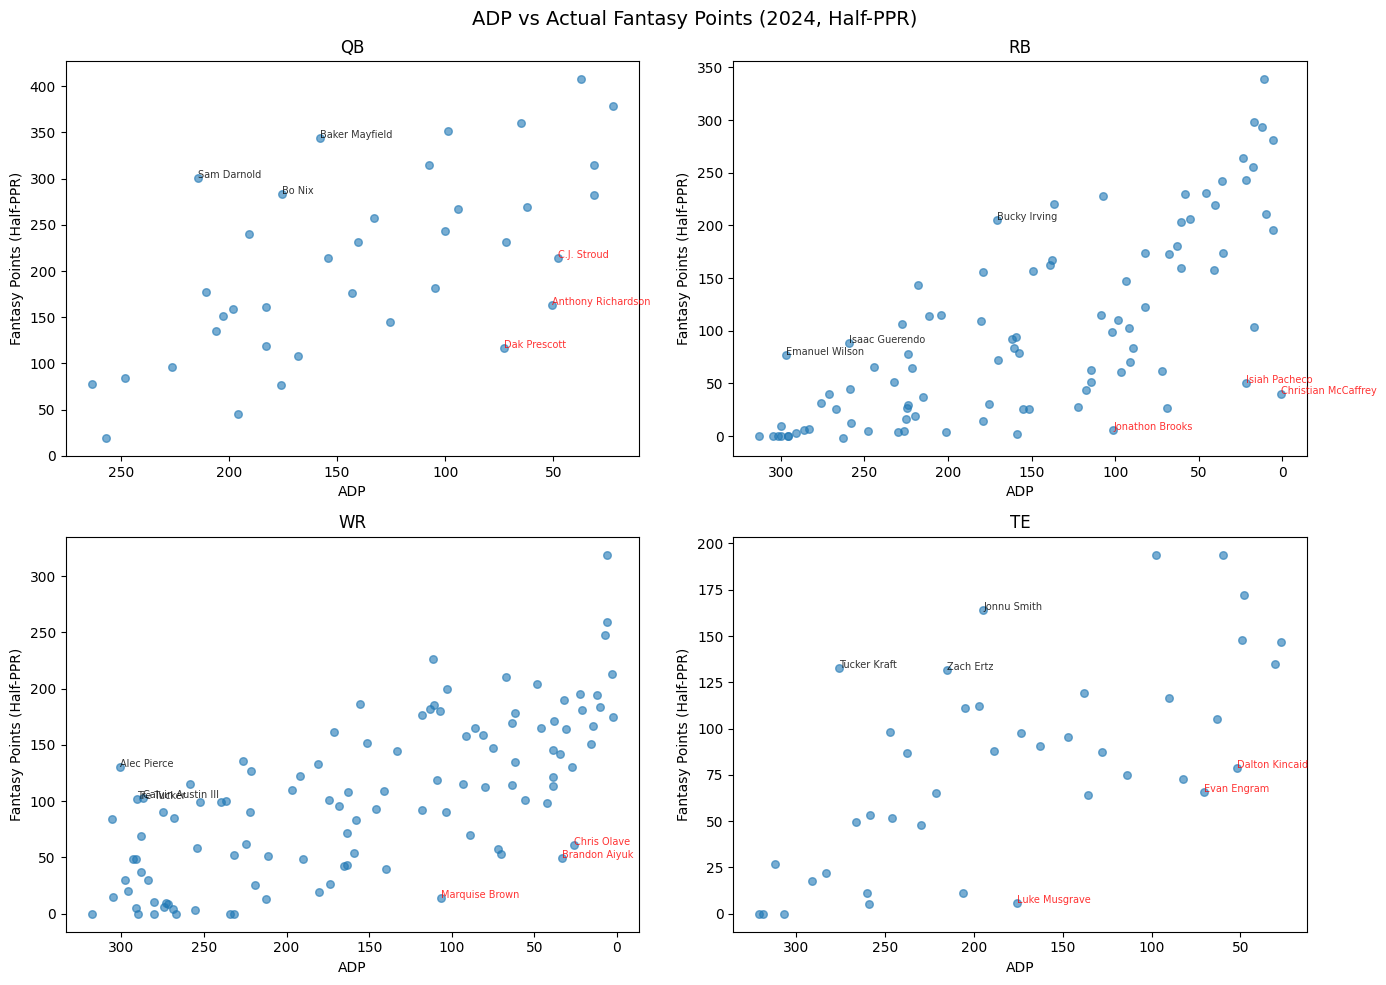

In [29]:
# Scatter: ADP vs Fantasy Points (2024 season, all positions)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("ADP vs Actual Fantasy Points (2024, Half-PPR)", fontsize=14)

for ax, pos in zip(axes.flat, ["QB", "RB", "WR", "TE"]):
    pos_data = analysis.filter(
        (pl.col("position") == pos) & (pl.col("season") == 2024)
    )
    x = pos_data["adp"].to_list()
    y = pos_data["seasonal_fantasy_points"].to_list()
    names = pos_data["player_display_name"].to_list()

    ax.scatter(x, y, alpha=0.6, s=30)
    ax.set_title(pos)
    ax.set_xlabel("ADP")
    ax.set_ylabel("Fantasy Points (Half-PPR)")
    ax.invert_xaxis()

    # Label top 3 value picks and top 3 busts
    top_value = pos_data.sort("value_over_adp", descending=True).head(3)
    top_busts = pos_data.sort("value_over_adp", descending=False).head(3)
    for row in top_value.iter_rows(named=True):
        ax.annotate(row["player_display_name"], (row["adp"], row["seasonal_fantasy_points"]),
                    fontsize=7, alpha=0.8)
    for row in top_busts.iter_rows(named=True):
        ax.annotate(row["player_display_name"], (row["adp"], row["seasonal_fantasy_points"]),
                    fontsize=7, alpha=0.8, color="red")

plt.tight_layout()
plt.show()

In [30]:
# Biggest value picks and busts across all seasons
print("=== TOP 15 VALUE PICKS (all seasons) ===")
print("Players who outperformed their ADP the most\n")
print(
    analysis
    .sort("value_over_adp", descending=True)
    .head(15)
    .select(["player_display_name", "position", "season", "adp",
             "seasonal_fantasy_points", "adp_pos_rank", "pos_finish_rank", "value_over_adp"])
)

print("\n=== TOP 15 BUSTS (all seasons) ===")
print("Players who underperformed their ADP the most\n")
print(
    analysis
    .sort("value_over_adp", descending=False)
    .head(15)
    .select(["player_display_name", "position", "season", "adp",
             "seasonal_fantasy_points", "adp_pos_rank", "pos_finish_rank", "value_over_adp"])
)

=== TOP 15 VALUE PICKS (all seasons) ===
Players who outperformed their ADP the most

shape: (15, 8)
┌──────────────┬──────────┬────────┬───────┬─────────────┬─────────────┬─────────────┬─────────────┐
│ player_displ ┆ position ┆ season ┆ adp   ┆ seasonal_fa ┆ adp_pos_ran ┆ pos_finish_ ┆ value_over_ │
│ ay_name      ┆ ---      ┆ ---    ┆ ---   ┆ ntasy_point ┆ k           ┆ rank        ┆ adp         │
│ ---          ┆ str      ┆ i64    ┆ f64   ┆ s           ┆ ---         ┆ ---         ┆ ---         │
│ str          ┆          ┆        ┆       ┆ ---         ┆ i32         ┆ i32         ┆ i32         │
│              ┆          ┆        ┆       ┆ f64         ┆             ┆             ┆             │
╞══════════════╪══════════╪════════╪═══════╪═════════════╪═════════════╪═════════════╪═════════════╡
│ Tyler Boyd   ┆ WR       ┆ 2018   ┆ 362.0 ┆ 183.1       ┆ 130         ┆ 17          ┆ 113         │
│ Darius       ┆ WR       ┆ 2019   ┆ 416.0 ┆ 146.0       ┆ 143         ┆ 35          ┆ 108 

Points and hit rate by draft round (12-team league):
hit_rate_pct = % of picks who finished as starters (top 12 QB, top 24 RB/WR, top 12 TE)
shape: (16, 6)
┌─────────────┬────────────┬───────────┬─────────┬──────────┬──────────────┐
│ draft_round ┆ mean_pts   ┆ std_pts   ┆ players ┆ hit_rate ┆ hit_rate_pct │
│ ---         ┆ ---        ┆ ---       ┆ ---     ┆ ---      ┆ ---          │
│ i32         ┆ f64        ┆ f64       ┆ u32     ┆ f64      ┆ f64          │
╞═════════════╪════════════╪═══════════╪═════════╪══════════╪══════════════╡
│ 1           ┆ 220.4425   ┆ 83.381043 ┆ 96      ┆ 0.822917 ┆ 82.3         │
│ 2           ┆ 204.056939 ┆ 80.703355 ┆ 98      ┆ 0.72449  ┆ 72.4         │
│ 3           ┆ 180.29814  ┆ 73.573842 ┆ 86      ┆ 0.697674 ┆ 69.8         │
│ 4           ┆ 162.778557 ┆ 71.107898 ┆ 97      ┆ 0.536082 ┆ 53.6         │
│ 5           ┆ 171.171959 ┆ 76.245364 ┆ 97      ┆ 0.463918 ┆ 46.4         │
│ …           ┆ …          ┆ …         ┆ …       ┆ …        ┆ …           

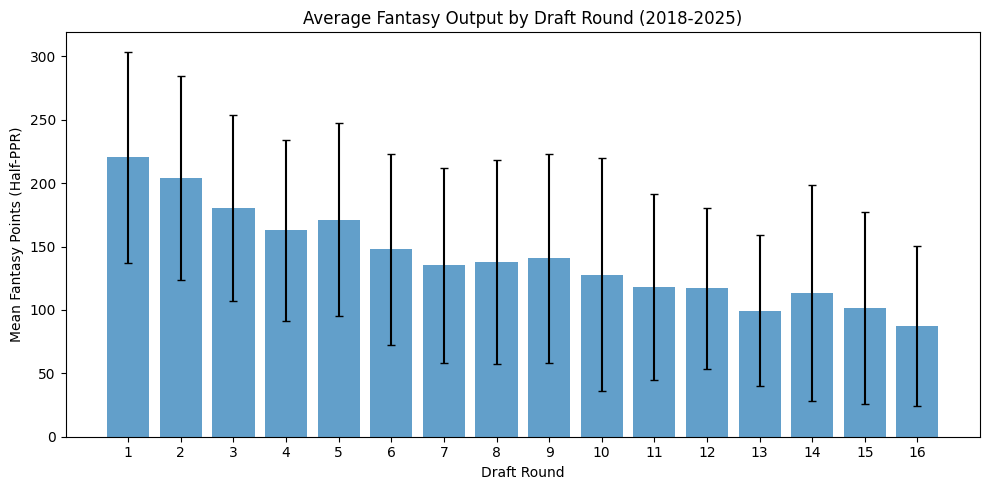

In [31]:
# ADP round analysis: how valuable are early picks vs late picks?
# Define draft rounds (12-team league, so round 1 = ADP 1-12, round 2 = 13-24, etc.)
analysis_rounds = analysis.with_columns(
    ((pl.col("adp") - 1) / 12).floor().cast(pl.Int32).add(1).alias("draft_round")
)

# Round-fair metric: hit rate = % of picks who finished as starters at their position.
# Starter = top 12 QB, top 24 RB, top 24 WR, top 12 TE (12-team, start 1/2/2/1 + flex).
# Early rounds aren't penalized for "can't beat ADP" — we just ask "did they deliver?"
starter_cutoff = pl.when(pl.col("position") == "QB").then(pl.col("pos_finish_rank") <= 12).when(pl.col("position") == "RB").then(pl.col("pos_finish_rank") <= 24).when(pl.col("position") == "WR").then(pl.col("pos_finish_rank") <= 24).when(pl.col("position") == "TE").then(pl.col("pos_finish_rank") <= 12).otherwise(False)
analysis_rounds = analysis_rounds.with_columns(starter_cutoff.alias("is_starter"))

round_stats = (
    analysis_rounds
    .group_by("draft_round")
    .agg(
        pl.col("seasonal_fantasy_points").mean().alias("mean_pts"),
        pl.col("seasonal_fantasy_points").std().alias("std_pts"),
        pl.len().alias("players"),
        pl.col("is_starter").mean().alias("hit_rate"),
    )
    .filter(pl.col("draft_round") <= 16)
    .sort("draft_round")
    .with_columns((pl.col("hit_rate") * 100).round(1).alias("hit_rate_pct"))
)

print("Points and hit rate by draft round (12-team league):")
print("hit_rate_pct = % of picks who finished as starters (top 12 QB, top 24 RB/WR, top 12 TE)")
print(round_stats)

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(round_stats["draft_round"].to_list(), round_stats["mean_pts"].to_list(),
       yerr=round_stats["std_pts"].to_list(), capsize=3, alpha=0.7)
ax.set_xlabel("Draft Round")
ax.set_ylabel("Mean Fantasy Points (Half-PPR)")
ax.set_title("Average Fantasy Output by Draft Round (2018-2025)")
ax.set_xticks(range(1, 17))
plt.tight_layout()
plt.show()

## 9b. Positional value snapshot (one season)

**§10** RAG text compares **positional ADP order** to **positional points finish** (same idea as `value_over_adp` in §9). This cell prints top / bottom player-seasons for a single year using the same ranks computed on the fly.

- `adp_pos_rank` — ordinal rank of ADP within `(season, position)` (1 = first drafted at that position).
- `pos_finish_rank` — ordinal rank of `seasonal_fantasy_points` within `(season, position)` (1 = highest scorer).
- `value_over_adp` = `adp_pos_rank - pos_finish_rank` (larger ⇒ better value vs peers).

Set `COMPARISON_YEAR` in the next cell. Requires in-memory `final` from the merge above.


In [32]:
import polars as pl

COMPARISON_YEAR = 2024

cmp_base = (
    final.filter(
        pl.col("season") == COMPARISON_YEAR,
        pl.col("adp").is_not_null(),
        pl.col("seasonal_fantasy_points").is_not_null(),
        pl.col("position").is_in(["QB", "RB", "WR", "TE"]),
    )
    .with_columns(
        pl.col("seasonal_fantasy_points")
        .rank(method="ordinal", descending=True)
        .over(["season", "position"])
        .cast(pl.Int32)
        .alias("pos_finish_rank"),
        pl.col("adp")
        .rank(method="ordinal", descending=False)
        .over(["season", "position"])
        .cast(pl.Int32)
        .alias("adp_pos_rank"),
    )
    .with_columns(
        (pl.col("adp_pos_rank") - pl.col("pos_finish_rank")).alias("value_over_adp")
    )
)

cols_show = [
    "player_display_name",
    "position",
    "adp",
    "seasonal_fantasy_points",
    "adp_pos_rank",
    "pos_finish_rank",
    "value_over_adp",
    "overall_points_rank",
    "position_points_rank",
]

print(f"=== {COMPARISON_YEAR}: top 15 by value_over_adp (steals vs positional ADP) ===")
print(
    cmp_base.select(cols_show)
    .sort("value_over_adp", descending=True, nulls_last=True)
    .head(15)
)

print(f"\n=== {COMPARISON_YEAR}: bottom 15 (busts by same metric) ===")
print(
    cmp_base.select(cols_show)
    .sort("value_over_adp", descending=False, nulls_last=True)
    .head(15)
)


=== 2024: top 15 by value_over_adp (steals vs positional ADP) ===
shape: (15, 9)
┌────────────┬──────────┬───────┬────────────┬───┬────────────┬────────────┬───────────┬───────────┐
│ player_dis ┆ position ┆ adp   ┆ seasonal_f ┆ … ┆ pos_finish ┆ value_over ┆ overall_p ┆ position_ │
│ play_name  ┆ ---      ┆ ---   ┆ antasy_poi ┆   ┆ _rank      ┆ _adp       ┆ oints_ran ┆ points_ra │
│ ---        ┆ str      ┆ f64   ┆ nts        ┆   ┆ ---        ┆ ---        ┆ k         ┆ nk        │
│ str        ┆          ┆       ┆ ---        ┆   ┆ i32        ┆ i32        ┆ ---       ┆ ---       │
│            ┆          ┆       ┆ f64        ┆   ┆            ┆            ┆ i64       ┆ i64       │
╞════════════╪══════════╪═══════╪════════════╪═══╪════════════╪════════════╪═══════════╪═══════════╡
│ Alec       ┆ WR       ┆ 301.0 ┆ 130.2      ┆ … ┆ 39         ┆ 68         ┆ 108       ┆ 40        │
│ Pierce     ┆          ┆       ┆            ┆   ┆            ┆            ┆           ┆           │
│ Tre Tuck

## 10. RAG note (deferred)

RAG is intentionally deferred for now while we prioritize the SQL-first path.

- Current historical data is fully structured, so text-to-SQL / Polars is the better fit for most questions.
- `ingest.py` and `vectorstore.py` are kept in the codebase as reference stubs for a later RAG phase.
- A future RAG pass should focus on truly unstructured in-season text (articles, reports, notes), not templated row summaries.

This notebook now focuses on data prep and validation for analytics + text-to-SQL.

## 11. Save processed data

Output files go to `data/processed/`:
1. `combined_stats_adp.parquet` — full combined table (stats + ADP + roster). Same table as `combined_stats_adp.csv` for spreadsheets (gitignored). `ingest.py` / §10 only need the core stat and rank columns.
2. `analysis_with_value.parquet` — matched players only, with value scores
3. `weekly_stats.parquet` — weekly stats as parquet for faster loading later


In [33]:
from pathlib import Path

processed_dir = Path("../data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

def round_floats(df):
    """Round all float columns to 2 decimals (but leave integer columns untouched)."""
    float_cols = [c for c, dtype in zip(df.columns, df.dtypes) if dtype == pl.Float64]
    return df.with_columns([pl.col(c).round(2).alias(c) for c in float_cols])

# 1. Full combined table (parquet for code; CSV optional for inspection in Excel / grep)
final_rounded = round_floats(final)
final_rounded.write_parquet(processed_dir / "combined_stats_adp.parquet")
final_rounded.write_csv(processed_dir / "combined_stats_adp.csv")
print(
    f"Saved combined_stats_adp.parquet + .csv: {final_rounded.shape[0]} rows, {final_rounded.shape[1]} cols"
)

# 2. Analysis subset with value scores
analysis_rounds_rounded = round_floats(analysis_rounds)
analysis_rounds_rounded.write_parquet(processed_dir / "analysis_with_value.parquet")
print(f"Saved analysis_with_value.parquet: {analysis_rounds_rounded.shape[0]} rows, {analysis_rounds_rounded.shape[1]} cols")

# 3. Weekly stats as parquet (much faster to load than CSV)
weekly_stats_rounded = round_floats(weekly_stats)
weekly_stats_rounded.write_parquet(processed_dir / "weekly_stats.parquet")
print(f"Saved weekly_stats.parquet: {weekly_stats_rounded.shape[0]} rows, {weekly_stats_rounded.shape[1]} cols")

print("\nAll processed data saved to data/processed/")
print("These files are the input for the RAG and analytics layers.")

Saved combined_stats_adp.parquet + .csv: 5415 rows, 25 cols
Saved analysis_with_value.parquet: 2627 rows, 30 cols
Saved weekly_stats.parquet: 48046 rows, 116 cols

All processed data saved to data/processed/
These files are the input for the RAG and analytics layers.


## 12. Validation checks

Run after saving processed parquets (**§11**). This section does **not** change data; it only reports whether common issues are absent:

- **Grain:** one row per `(player_id, season)` in the seasonal CSV and in `combined_stats_adp.parquet`
- **Ranks:** `overall_points_rank` / `position_points_rank` present; each season still has a true WR1 (`min` positional rank for WR is 1)
- **Trades / totals:** sum of weekly `fantasy_points_half_ppr` matches `seasonal_fantasy_points` (same IDs and seasons as in the seasonal file)
- **Names:** `match_key` + `season` should not map to multiple `player_id`s (duplicate-name collisions)

**Severity:** *Hard failures* (grain, ranks, weekly vs seasonal mismatch) should be fixed before RAG or modeling. *Warnings* (e.g. `match_key` collisions) are expected until you curate name matching — note them when interpreting ADP joins.


In [34]:
# Validation checks — reads artifacts from disk (safe to run standalone after §11)
from pathlib import Path

import polars as pl

processed_dir = Path("../data/processed")
raw_dir = Path("../data/raw")

issues: list[str] = []
warnings: list[str] = []

combined = pl.read_parquet(processed_dir / "combined_stats_adp.parquet")
seasonal = pl.read_csv(raw_dir / "player_stats_2018_2025_season.csv", separator="\t")
weekly = pl.read_parquet(processed_dir / "weekly_stats.parquet")

# --- 1. Grain: one row per player-season in seasonal CSV ---
dup_seasonal = (
    seasonal.group_by(["player_id", "season"])
    .len()
    .filter(pl.col("len") > 1)
)
if dup_seasonal.height > 0:
    issues.append(
        f"Seasonal CSV: {dup_seasonal.height} duplicate (player_id, season) — inspect fetch_stats group_by."
    )
else:
    print("OK: Seasonal CSV — one row per (player_id, season).")

# --- 2. Grain: combined parquet (stats × ADP × roster) ---
dup_combined = (
    combined.group_by(["player_id", "season"])
    .len()
    .filter(pl.col("len") > 1)
)
if dup_combined.height > 0:
    issues.append(
        f"Combined parquet: {dup_combined.height} duplicate (player_id, season) — inspect joins/dedup."
    )
else:
    print("OK: Combined parquet — one row per (player_id, season).")

# --- 3. Rank columns populated for scored rows ---
for col in ("overall_points_rank", "position_points_rank"):
    if col not in combined.columns:
        issues.append(f"Combined missing column: {col}")
if "overall_points_rank" in combined.columns:
    bad = combined.filter(
        pl.col("seasonal_fantasy_points").is_not_null()
        & pl.col("overall_points_rank").is_null()
    ).height
    if bad:
        issues.append(f"{bad} combined rows with points but null overall_points_rank")
    else:
        print("OK: Ranks non-null wherever seasonal_fantasy_points is set.")

# --- 4. Each season has a WR leader (min positional rank for WR is 1); allow ties (multiple WRs at rank 1) ---
wr_floor = seasonal.filter(pl.col("position") == "WR").group_by("season").agg(
    pl.col("position_points_rank").min().alias("min_wr_rank")
)
off = wr_floor.filter(pl.col("min_wr_rank") != 1)
if off.height > 0:
    issues.append(f"Some seasons have no WR with rank 1: {off}")
else:
    wr_ones = seasonal.filter(
        (pl.col("position") == "WR") & (pl.col("position_points_rank") == 1)
    ).group_by("season").len()
    ties = wr_ones.filter(pl.col("len") > 1)
    print(
        f"OK: Every season has WR rank-1 finishers ({wr_ones.height} seasons). "
        f"Tied WR1 rows (same season): {ties.height} seasons with ties."
    )

# --- 5. Weekly half-PPR sums match seasonal file (catches trade splits if seasonal agg were wrong) ---
wsum = weekly.group_by(["player_id", "season"]).agg(
    pl.col("fantasy_points_half_ppr").sum().alias("wpts")
)
cmp = seasonal.select(["player_id", "season", "seasonal_fantasy_points"]).join(
    wsum,
    on=["player_id", "season"],
    how="inner",
)
cmp = cmp.with_columns(
    (pl.col("seasonal_fantasy_points") - pl.col("wpts")).abs().alias("diff")
)
max_diff = cmp["diff"].max()
if max_diff is None or max_diff > 0.02:
    issues.append(
        f"Weekly sum vs seasonal max |diff| = {max_diff} (tolerance 0.02)"
    )
else:
    print(f"OK: Weekly sums match seasonal totals (max |diff| = {max_diff:.4f}).")

# --- 6. match_key collisions: same normalized name + season should not attach to multiple player_ids ---
if "match_key" in combined.columns:
    bad_keys = (
        combined.filter(pl.col("match_key").is_not_null())
        .group_by(["match_key", "season"])
        .agg(pl.col("player_id").n_unique().alias("n_ids"))
        .filter(pl.col("n_ids") > 1)
    )
    if bad_keys.height > 0:
        warnings.append(
            f"match_key+season → multiple player_ids in {bad_keys.height} groups "
            "(common for duplicate names, e.g. two Mike Williams — verify ADP↔stats pairing)."
        )
        print(bad_keys.head(15))
    else:
        print("OK: No match_key+season with multiple player_ids.")

# --- Summary ---
print("\n--- Validation summary ---")
if issues:
    print("Hard failures (fix before RAG/model):")
    for msg in issues:
        print(f"  - {msg}")
else:
    print("No hard failures (grain, ranks, weekly vs seasonal).")

if warnings:
    print("Warnings (review when tuning matching):")
    for msg in warnings:
        print(f"  - {msg}")

if not issues and not warnings:
    print("All checks passed.")

OK: Seasonal CSV — one row per (player_id, season).
OK: Every season has WR rank-1 finishers (8 seasons). Tied WR1 rows (same season): 0 seasons with ties.
OK: Weekly sums match seasonal totals (max |diff| = 0.0000).
shape: (10, 3)
┌────────────────┬────────┬───────┐
│ match_key      ┆ season ┆ n_ids │
│ ---            ┆ ---    ┆ ---   │
│ str            ┆ i64    ┆ u32   │
╞════════════════╪════════╪═══════╡
│ matt jones     ┆ 2021   ┆ 2     │
│ nick williams  ┆ 2025   ┆ 2     │
│ eric rogers    ┆ 2022   ┆ 2     │
│ ryan griffin   ┆ 2019   ┆ 2     │
│ aj green       ┆ 2019   ┆ 2     │
│ chris johnson  ┆ 2018   ┆ 2     │
│ michael thomas ┆ 2021   ┆ 2     │
│ frank gore     ┆ 2024   ┆ 2     │
│ keith smith    ┆ 2018   ┆ 2     │
│ brandon smith  ┆ 2023   ┆ 2     │
└────────────────┴────────┴───────┘

--- Validation summary ---
Hard failures (fix before RAG/model):
  - Combined parquet: 7 duplicate (player_id, season) — inspect joins/dedup.
  - 359 combined rows with points but null overal

## Summary

### Data processed
- 48K+ weekly stat rows, 5K+ seasonal stat rows (nflreadpy, 2018-2025)
- 3,200 ADP entries (FantasyPros CSVs)
- ID-based matching through `load_ff_playerids()` bridge table
- Combined DataFrame: stats + ADP + roster metadata
- Value scoring: position rank vs ADP rank per season (§9)

### Notes
- Most unmatched ADP rows are DST teams (not in player stats) or holdouts/retirements
- Early-round picks produce more points on average but higher variance too
- `value_over_adp` metric captures steals and busts pretty well

### RAG text (`ingest.py`)
- **§10** walks through `player_season_to_text`, the ingest filter, and `build_documents()`
- Documents use **within-position** draft value (ADP rank vs points rank), not overall-rank curves

### Next: build the RAG system
Processed parquet files are ready. Next steps:
1. Embed `build_documents()` output in ChromaDB, wire up LangChain
2. Build analytics layer (VOR, trade tools) on top of projections later
